<a href="https://colab.research.google.com/github/RocafellaGitub/MaikanoRocafellaSteve/blob/main/DEEP_LEARNING_(DIABETES).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

IMPORT DATASET

In [5]:
df=pd.read_csv('Diabetes-Classification.csv')
df.head()

,Age,Gender,BMI,Blood Pressure,FBS,HbA1c,Family History of Diabetes,Smoking,Diet,Exercise,Diagnosis
0,45,Male,25.0,Normal,100,5.7,No,No,Healthy,Regular,No
1,55,Female,30.0,High,120,6.4,Yes,Yes,Poor,No,Yes
2,65,Male,35.0,High,140,7.1,Yes,Yes,Poor,No,Yes
3,75,Female,40.0,High,160,7.8,Yes,Yes,Poor,No,Yes
4,40,Male,20.0,Normal,80,5.0,No,No,Healthy,NaN,No


In [6]:
df.isnull() .sum()

,0
Age,0
Gender,0
BMI,3
Blood Pressure,0
FBS,0
HbA1c,0
Family History of Diabetes,2
Smoking,2
Diet,2
Exercise,1


In [7]:
df= df.dropna()
df.isnull() .sum()

,0
Age,0
Gender,0
BMI,0
Blood Pressure,0
FBS,0
HbA1c,0
Family History of Diabetes,0
Smoking,0
Diet,0
Exercise,0


#PREPROCESSING
IDENTIFY WHICH IS CATEGORICAL DATA AND NUMERICAL DATA
IDENTIFY THE TARGET COLUMN

In [8]:
# Check column names
print("\nColumn Names:")
print(df.columns)

# Preprocessing
# Identify categorical and numerical columns
categorical_cols = ['Gender', 'Blood Pressure', 'Family History of Diabetes', 'Smoking', 'Diet', 'Exercise']
numerical_cols = ['Age', 'BMI', 'FBS', 'HbA1c']

# Target column
target_column = 'Diagnosis'


Column Names:
Index(['Age', 'Gender', 'BMI', 'Blood Pressure', 'FBS', 'HbA1c',
       'Family History of Diabetes', 'Smoking', 'Diet', 'Exercise',
       'Diagnosis'],
      dtype='object')


#CREATE A COLUMN TRANSFORMER TO PREPROCESS THE DATA IN THE COLUMNS
NUMERICAL COLS AND CATEGORICAL COLS


In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

TRAIN SPLIT AND TEST THE DATASET

In [10]:
# Split features and target
X = df.drop('Diagnosis', axis=1)
y = df['Diagnosis']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [11]:
# Apply preprocessing
X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

# Convert y_train and y_test to binary (label encoding)
y_train = y_train.map({'No': 0, 'Yes': 1}).values
y_test = y_test.map({'No': 0, 'Yes': 1}).values

In [12]:
# Convert X_train_scaled and X_test_scaled to NumPy arrays (Tensorflow does not accept pandas dataframe as input, it accepts either Tensorflow tensors or NumPy arrays)
X_train_scaled = X_train_scaled.astype('float32')
X_test_scaled = X_test_scaled.astype('float32')

#INSTALL TENSORFLOW

In [13]:
!pip install tensorflow

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout,Input

DESIGN MY NN TENSORFLOW MLP MODEL

In [14]:
#suppress warnings
tf.compat.v1.logging.set_verbosity(tf.compat.v1.logging.ERROR)

# Build the TensorFlow MLP model
tf_model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

#COMPILE AND TRAIN THE NEURAL NETWORK MODEL


In [15]:
# Compile the model
tf_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
history = tf_model.fit(X_train_scaled, y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=1)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 281ms/step - accuracy: 0.5349 - loss: 0.7049 - val_accuracy: 0.7059 - val_loss: 0.6668
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 126ms/step - accuracy: 0.5388 - loss: 0.6882 - val_accuracy: 0.5882 - val_loss: 0.6377
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.6665 - loss: 0.6200 - val_accuracy: 0.5882 - val_loss: 0.6142
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.8218 - loss: 0.5541 - val_accuracy: 0.5882 - val_loss: 0.5927
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.7673 - loss: 0.5267 - val_accuracy: 0.6471 - val_loss: 0.5754
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.8180 - loss: 0.4950 - val_accuracy: 0.6471 - val_loss: 0.5621
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - accuracy: 0.8141 - loss: 0.4824 - val_accuracy: 0.6471 - val_loss: 0.5500
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - accuracy: 0.7945 - loss: 0.4814 - val_accuracy: 0.6471 - val_loss: 0

# Evaluate the model on the test set

In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

y_pred_tf = (tf_model.predict(X_test_scaled) > 0.5).astype(int)
print("\nTensorFlow MLP Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_tf))
print("Classification Report:")
print(classification_report(y_test, y_pred_tf))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_tf))
#y_train_pred = tf_model.predict(X_train_scaled)



2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step

TensorFlow MLP Performance:
Accuracy: 0.8888888888888888
Classification Report:
              precision    recall  f1-score   support

           0       0.87      1.00      0.93        27
           1       1.00      0.56      0.71         9

    accuracy                           0.89        36
   macro avg       0.94      0.78      0.82        36
weighted avg       0.90      0.89      0.88        36

Confusion Matrix:
[[27  0]
 [ 4  5]]


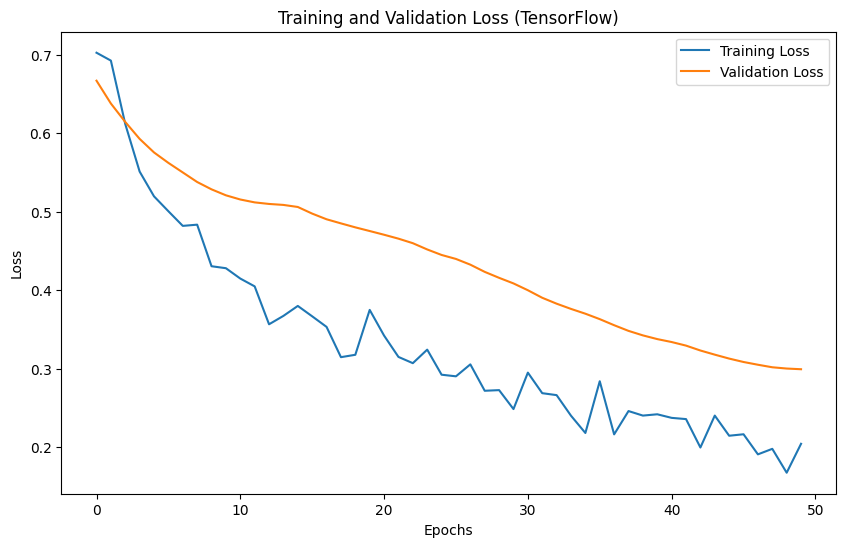

In [17]:
# Plot training history
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss (TensorFlow)')
plt.legend()
plt.show()

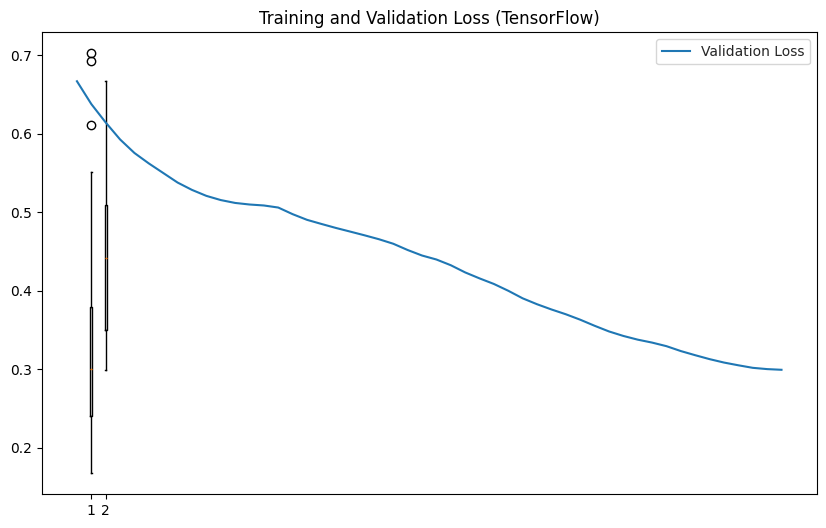

In [18]:
plt.figure(figsize=(10, 6))
plt.boxplot([history.history['loss'], history.history['val_loss']])
#plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
sns.set_style("whitegrid")

#plt.xlabel('Epochs')
#plt.ylabel('Loss')
plt.title('Training and Validation Loss (TensorFlow)')
plt.legend()
plt.show()

#VISUALIZATION - ASSIGNMENT

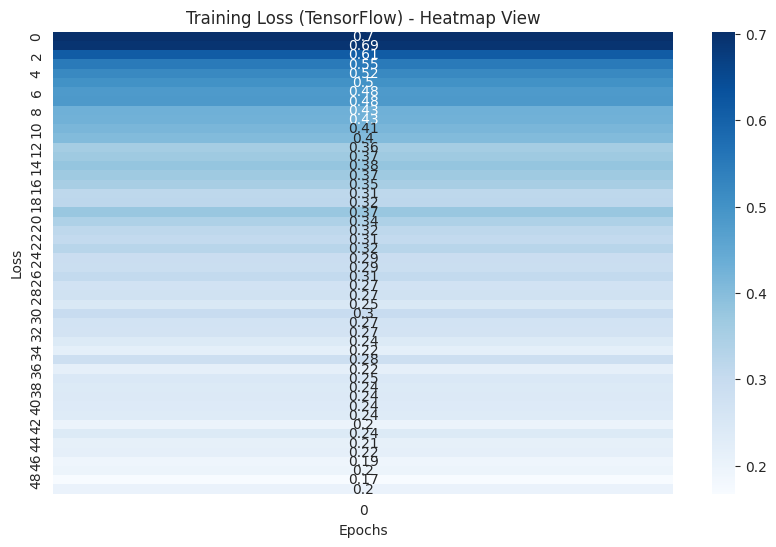

In [19]:
#plt.plot(history.history['loss'], label='Training Loss')
#plt.plot(history.history['val_loss'], label='Validation Loss')
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
sns.heatmap(np.array(history.history['loss']).reshape(-1, 1), annot=True, cmap='Blues') # Reshape to a 2D array
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss (TensorFlow) - Heatmap View') # Updated title for clarity
plt.show()

#CONFUSION MATRIX - ASSIGNMENT

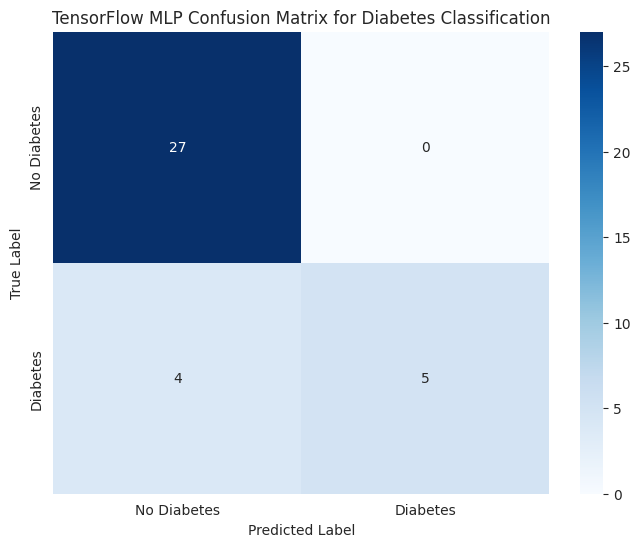

In [31]:
# Confusion Matrix

y_pred_labels = y_pred_tf.flatten() # Flatten to 1D array
conf_matrix = confusion_matrix(y_test, y_pred_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=['No Diabetes', 'Diabetes'], yticklabels=['No Diabetes', 'Diabetes'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("TensorFlow MLP Confusion Matrix for Diabetes Classification")
plt.show()

#CLASSIFICATION MATRIX TENSORFLOW - ASSIGNMENT

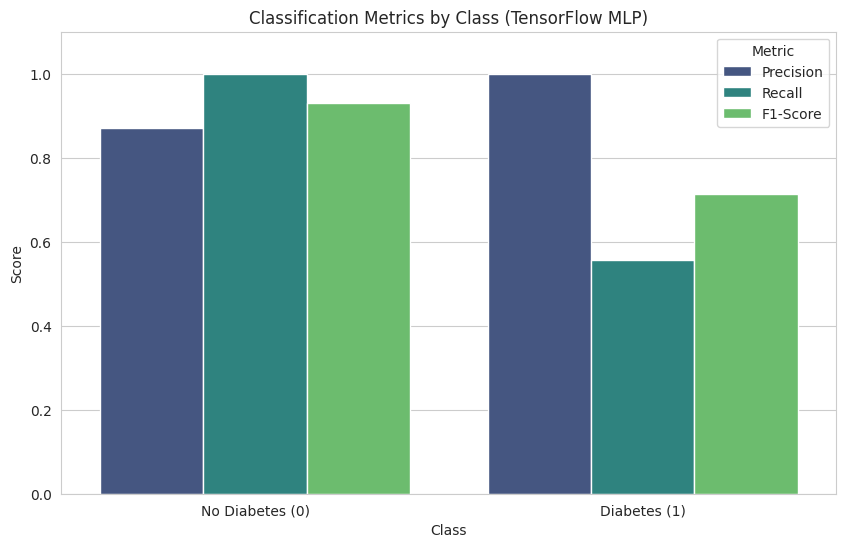

In [38]:
# Classification Metrics Per Class

from sklearn.metrics import classification_report

# Generate classification report as a dictionary
report = classification_report(y_test, y_pred_tf, output_dict=True)

# Extract metrics for class 0 ('No Diabetes') and class 1 ('Diabetes')
metrics_data = {
    'Class': ['No Diabetes (0)', 'Diabetes (1)'],
    'Precision': [report['0']['precision'], report['1']['precision']],
    'Recall': [report['0']['recall'], report['1']['recall']],
    'F1-Score': [report['0']['f1-score'], report['1']['f1-score']]
}

df_metrics = pd.DataFrame(metrics_data)

# Melt the DataFrame for easier plotting with seaborn
df_melted = df_metrics.melt(id_vars='Class', var_name='Metric', value_name='Score')

plt.figure(figsize=(10, 6))
sns.barplot(x='Class', y='Score', hue='Metric', data=df_melted, palette='viridis')
plt.ylim(0, 1.1) # Set y-axis limit to accommodate scores up to 1
plt.xlabel('Class')
plt.ylabel('Score')
plt.title('Classification Metrics by Class (TensorFlow MLP)')
plt.legend(title='Metric')
plt.show()

#PYTORCH

In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

In [21]:
# Load the Dataset

# Define transformations: Convert images to tensors and normalize them
transform = transforms.Compose([
    transforms.ToTensor(),  # Convert images to PyTorch tensors
    transforms.Normalize((0.5,), (0.5,))  # Normalize pixel values to [-1, 1]
])

# Download and load the training dataset
train_dataset = torchvision.datasets.MNIST(
    root='./data', train=True, transform=transform, download=True
)

# Download and load the test dataset
test_dataset = torchvision.datasets.MNIST(
    root='./data', train=False, transform=transform, download=True
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 40.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.19MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 9.31MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.45MB/s]


In [22]:
# Create Data Loaders
# Define batch size
batch_size = 64

# Create DataLoaders for training and testing
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)


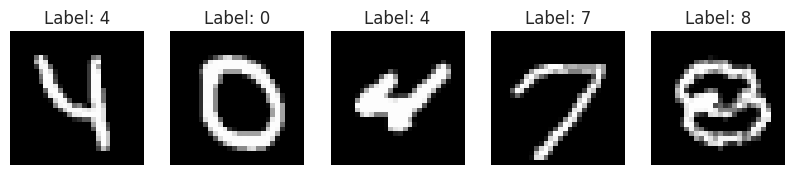

In [23]:
# Visualize Some Samples

# Function to display images
def show_images(images, labels):
    images = images.numpy()  # Convert tensors to numpy arrays
    fig, axes = plt.subplots(1, len(images), figsize=(10, 2))

    for i, ax in enumerate(axes):
        ax.imshow(images[i].squeeze(), cmap='gray')  # Remove color channel for grayscale images
        ax.set_title(f'Label: {labels[i].item()}')
        ax.axis('off')

# Get a batch of images from the train_loader
data_iter = iter(train_loader)
images, labels = next(data_iter)

# Show first 5 images
show_images(images[:5], labels[:5])
plt.show()

In [24]:
# Define the Neural Network Model

class NeuralNet(nn.Module):
    def __init__(self):
        super(NeuralNet, self).__init__()

        # Fully connected layers
        self.fc1 = nn.Linear(28*28, 128)  # Input layer → Hidden layer 1
        self.fc2 = nn.Linear(128, 64)     # Hidden layer 1 → Hidden layer 2
        self.fc3 = nn.Linear(64, 10)      # Hidden layer 2 → Output layer

        # Define Leaky ReLU with negative slope (default is 0.01)
        self.leaky_relu = nn.LeakyReLU(negative_slope=0.01)

    def forward(self, x):
        x = x.view(-1, 28*28)  # Flatten the image to (batch_size, 784)
        x = self.leaky_relu(self.fc1(x))  # Leaky ReLU for hidden layer 1
        x = self.leaky_relu(self.fc2(x))  # Leaky ReLU for hidden layer 2
        x = self.fc3(x)  # Output logits (no activation, since we use CrossEntropyLoss)
        return x

# Create model instance
model = NeuralNet()
print(model)  # Display model architecture

NeuralNet(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
  (leaky_relu): LeakyReLU(negative_slope=0.01)
)


In [25]:
# Define the loss function (Cross-Entropy for classification tasks)
criterion = nn.CrossEntropyLoss()

# Define the optimizer (Stochastic Gradient Descent)
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

print("Loss function and optimizer initialized!")

Loss function and optimizer initialized!



#
1.   DEFINE THE LOSS FUNCTION
2.   DEFINE THE OPTIMIZER



In [26]:
# Define the loss function (Cross-Entropy for classification tasks)
criterion = nn.CrossEntropyLoss()

# Define the optimizer (Stochastic Gradient Descent)
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

print("Loss function and optimizer initialized!")

Loss function and optimizer initialized!


#TRAIN THE MODEL

In [27]:
# Train the Model
num_epochs = 10  # Number of times the model sees the entire dataset

for epoch in range(num_epochs):  # Loop through the dataset multiple times
    running_loss = 0.0  # Track loss per epoch

    for images, labels in train_loader:
        # 1. Zero the gradient buffers
        optimizer.zero_grad()

        # 2. Forward pass
        outputs = model(images)

        # 3. Compute loss
        loss = criterion(outputs, labels)

        # 4. Backward pass (compute gradients)
        loss.backward()

        # 5. Update weights
        optimizer.step()

        # 6. Accumulate loss
        running_loss += loss.item()

    # Print loss after each epoch
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}")

print("Training complete!")

Epoch [1/10], Loss: 0.4241
Epoch [2/10], Loss: 0.1806
Epoch [3/10], Loss: 0.1317
Epoch [4/10], Loss: 0.1086
Epoch [5/10], Loss: 0.0899
Epoch [6/10], Loss: 0.0764
Epoch [7/10], Loss: 0.0682
Epoch [8/10], Loss: 0.0615
Epoch [9/10], Loss: 0.0547
Epoch [10/10], Loss: 0.0464
Training complete!


#EVALUATE THE MODEL

In [28]:

correct = 0
total = 0

# Disable gradient computation for evaluation (faster and memory-efficient)
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)  # Forward pass
        _, predicted = torch.max(outputs, 1)  # Get class with highest probability
        total += labels.size(0)  # Total test samples
        correct += (predicted == labels).sum().item()  # Count correct predictions

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 97.58%


#DISPLAY PREDICTION OF SAMPLE IMAGE
#GET A BATCH OF TEST IMAGES

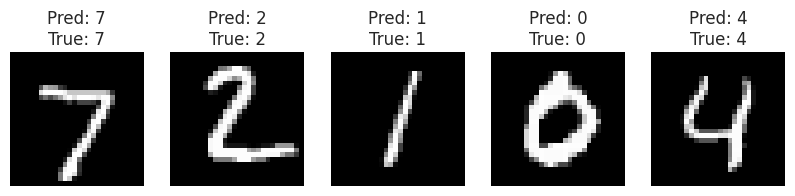

In [29]:
# Display Predictions on Sample Images
# Get a batch of test images
data_iter = iter(test_loader)
images, labels = next(data_iter)

# Get model predictions
with torch.no_grad():
    outputs = model(images)
    _, predicted = torch.max(outputs, 1)

# Function to display images with predicted labels
def show_predictions(images, labels, predicted):
    images = images.numpy()
    fig, axes = plt.subplots(1, 5, figsize=(10, 2))

    for i, ax in enumerate(axes):
        ax.imshow(images[i].squeeze(), cmap='gray')
        ax.set_title(f'Pred: {predicted[i].item()}\nTrue: {labels[i].item()}')
        ax.axis('off')

# Show the first 5 test images with predictions
show_predictions(images[:5], labels[:5], predicted[:5])
plt.show()